In [2]:
# Importing the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing the dataset
from pathlib import Path


data_path = Path('data/raw/Customer_churn.csv')
if not data_path.exists():
    data_path = Path('../data/raw/Customer_churn.csv')

df = pd.read_csv(data_path)

In [8]:
# Checking the shape of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]}")

The dataset has 7043 rows and 21


In [9]:
# Checking the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Fixing TotalCharges
print("Before conversion:")
print(df["TotalCharges"].dtype)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("\nAfter conversion:")
print(df["TotalCharges"].dtype)

print("\nMissing values created by conversion:")
print(df["TotalCharges"].isna().sum())

Before conversion:
float64

After conversion:
float64

Missing values created by conversion:
11


In [ ]:
# Showing rows where TotalCharges could not be converted
invalid_totalcharges = df[df["TotalCharges"].isna()]

print("Rows with missing TotalCharges:")
display(invalid_totalcharges)

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
)

missing_summary.columns = [
    "Column",
    "Missing_Count"
]

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] /
    len(df) * 100
)

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Column,Missing_Count,Missing_Percentage
19,TotalCharges,11,0.156183
1,gender,0,0.000000
2,SeniorCitizen,0,0.000000
3,Partner,0,0.000000
0,customerID,0,0.000000
4,Dependents,0,0.000000
5,tenure,0,0.000000
7,MultipleLines,0,0.000000
6,PhoneService,0,0.000000
9,OnlineSecurity,0,0.000000


In [8]:
# Analysing duplicates
duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64


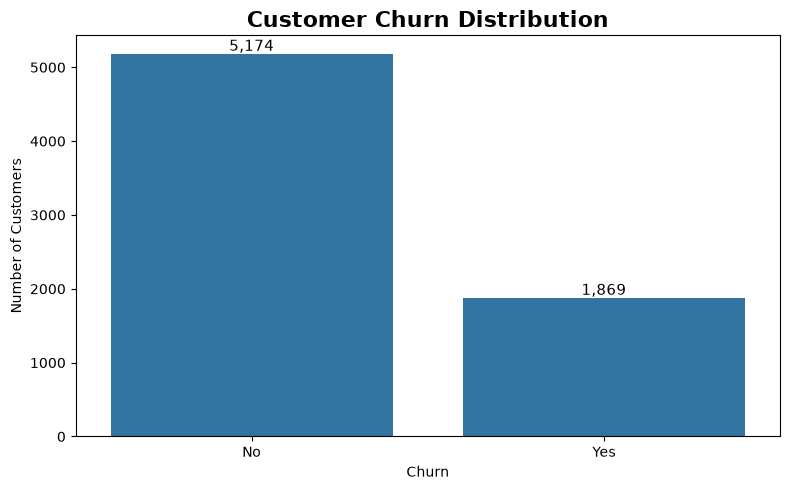

In [11]:
# Churn Distribution Bar Chart

churn_counts = df["Churn"].value_counts()

print(churn_counts)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    ax=ax
)

ax.set_title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    ax.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center",
        fontsize=11
    )

reports_dir = Path("reports")
if not reports_dir.exists() and Path("../reports").exists():
    reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(
    reports_dir / "01_churn_distribution_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

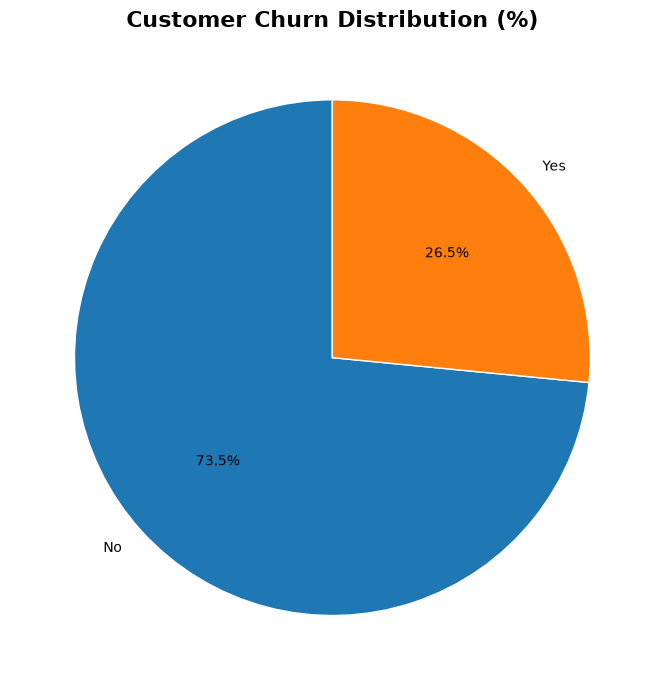

In [13]:
# Churn Distribution Pie Chart

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

ax.set_title(
    "Customer Churn Distribution (%)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    reports_dir / "02_churn_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

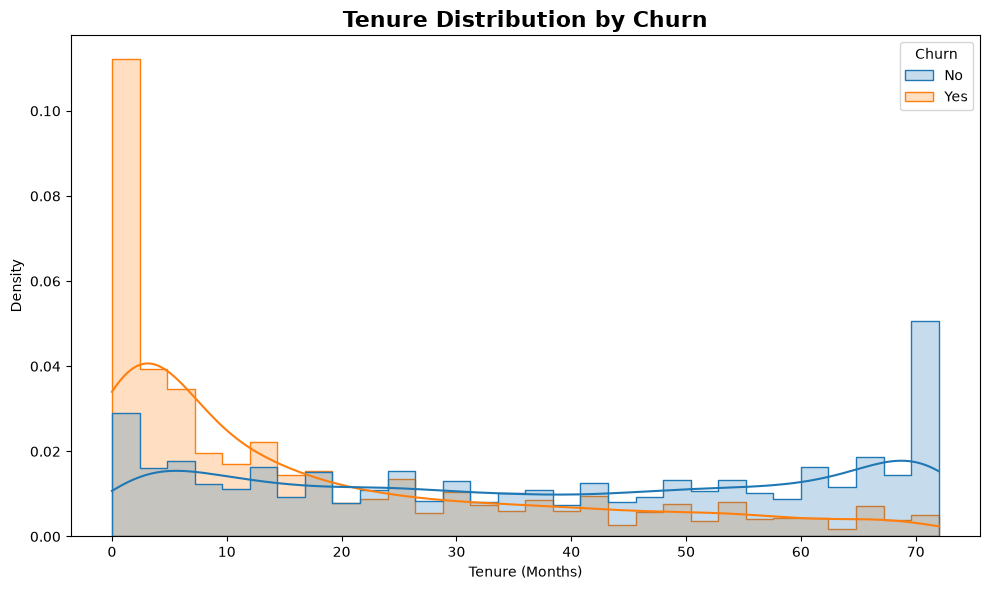

In [15]:
# ============================================================
# 11. TENURE DISTRIBUTION BY CHURN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax
)

ax.set_title(
    "Tenure Distribution by Churn",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Density")

plt.tight_layout()

plt.savefig(
    reports_dir / "03_tenure_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

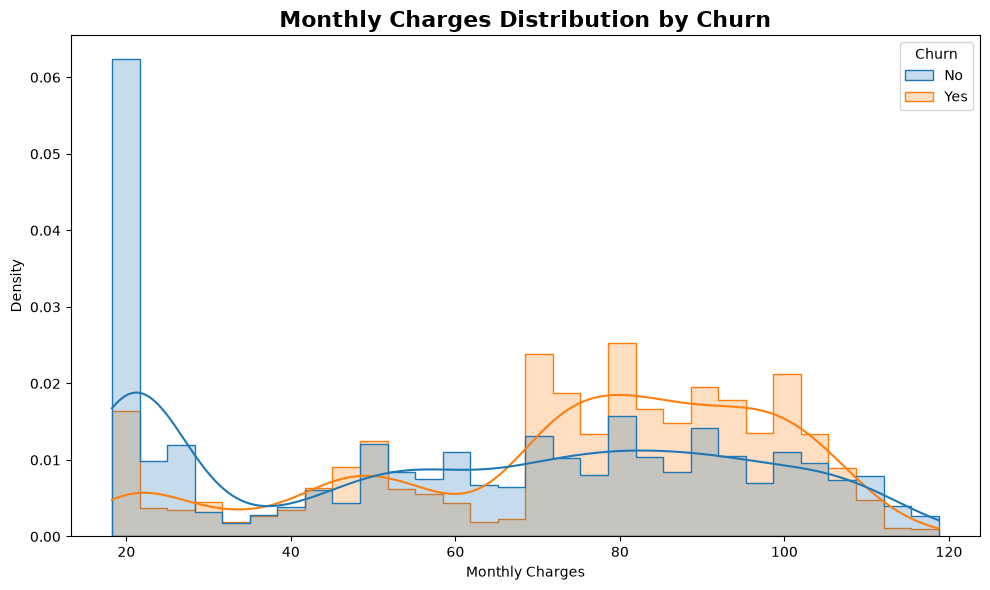

In [17]:
#Monthly Charges Distribution by Churn

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax
)

ax.set_title(
    "Monthly Charges Distribution by Churn",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Density")

plt.tight_layout()

plt.savefig(
    reports_dir / "04_monthly_charges_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [19]:
# Churn rate by categorical features

categorical_columns = [
    column
    for column in df.select_dtypes(include="object").columns
    if column not in ["customerID", "Churn"]
]

print("Categorical features:")
print(categorical_columns)

# Create a dictionary to store results
churn_rate_tables = {}

for column in categorical_columns:

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    churn_rate_tables[column] = churn_rate

    print("\n" + "=" * 70)
    print(f"CHURN RATE BY {column.upper()}")
    print("=" * 70)

    display(
        churn_rate.to_frame("Churn Rate (%)")
    )

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

CHURN RATE BY GENDER


,Churn Rate (%)
gender,
Female,26.920872
Male,26.160338



CHURN RATE BY PARTNER


,Churn Rate (%)
Partner,
No,32.957979
Yes,19.664903



CHURN RATE BY DEPENDENTS


...

,Churn Rate (%)
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858



CHURN RATE BY PAPERLESSBILLING


,Churn Rate (%)
PaperlessBilling,
Yes,33.565092
No,16.330084



CHURN RATE BY PAYMENTMETHOD


,Churn Rate (%)
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


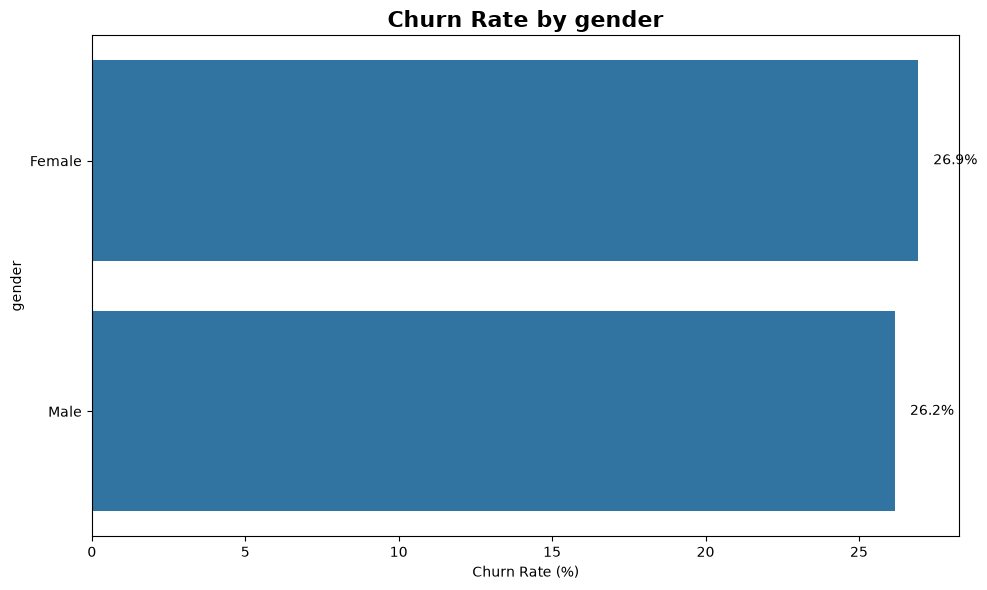

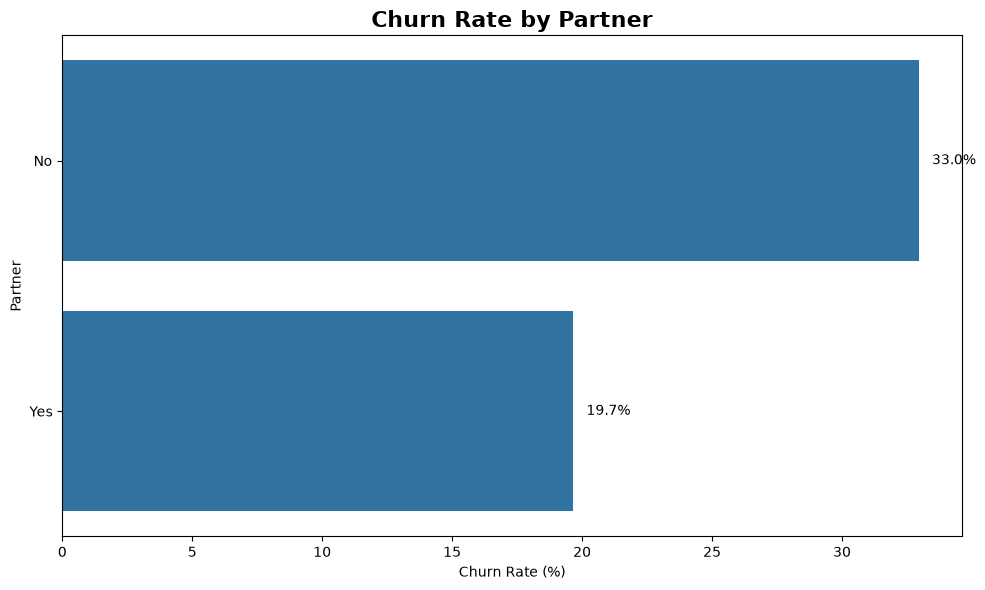

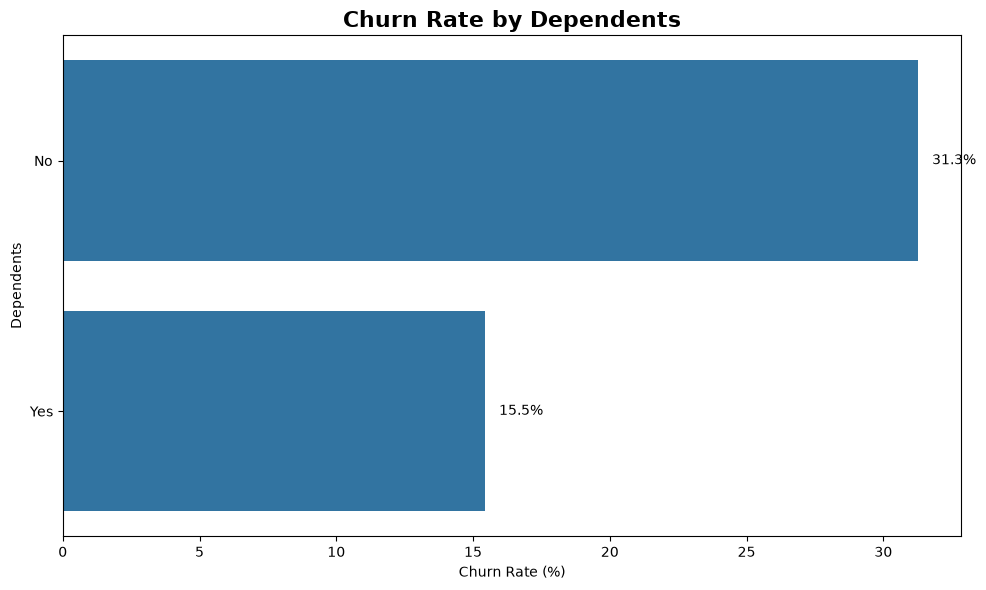

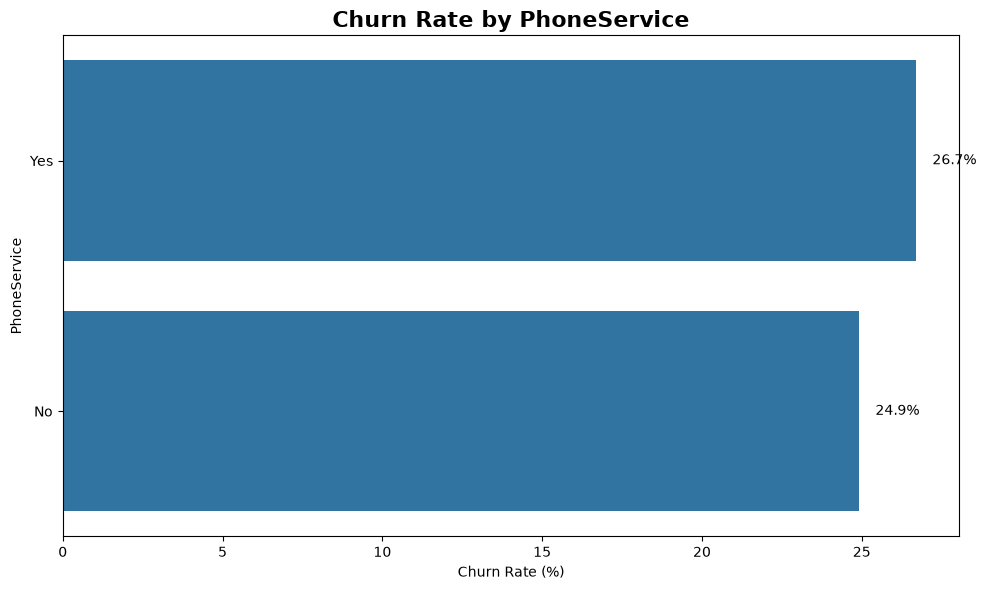

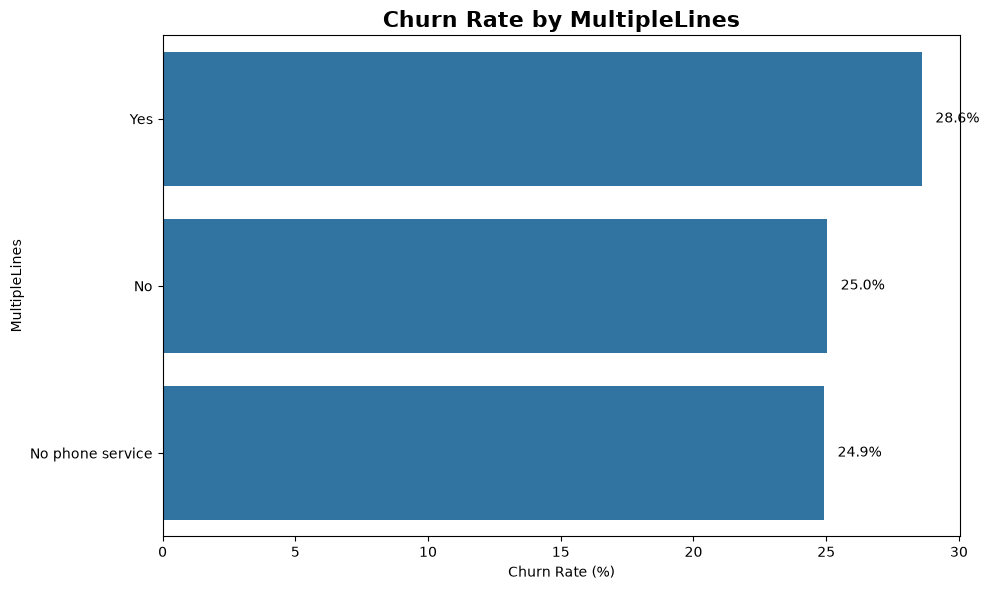

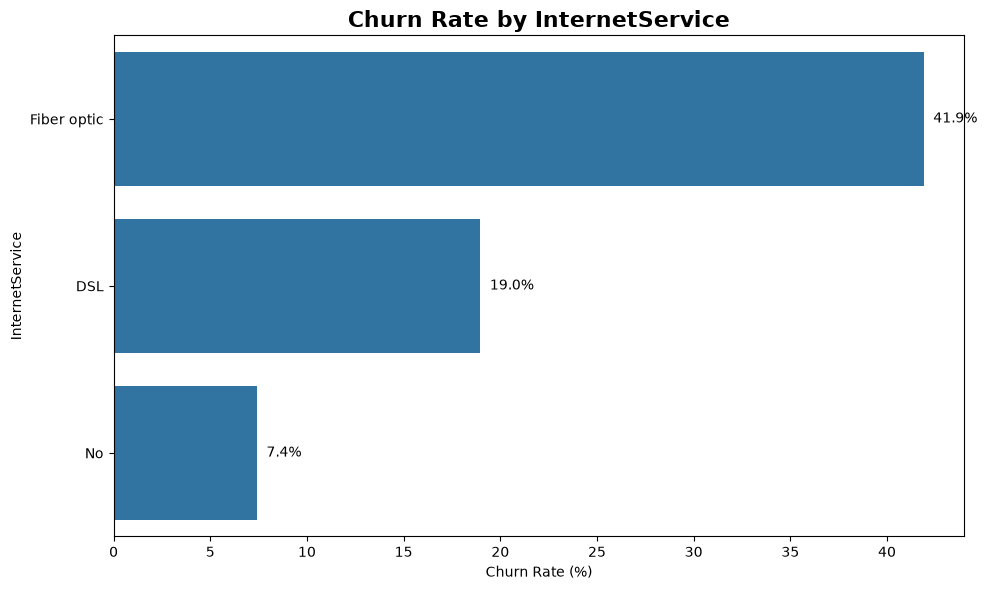

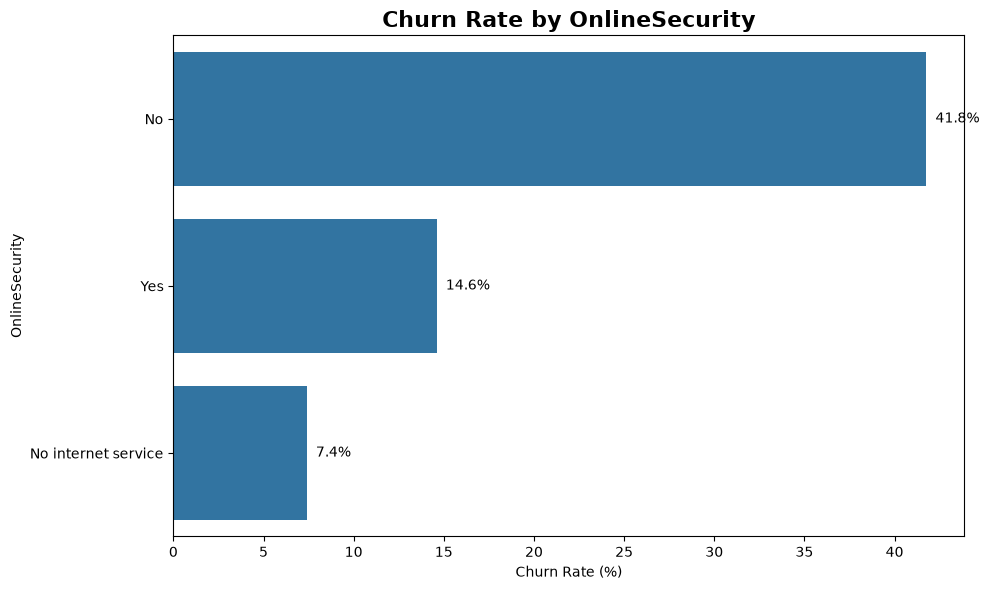

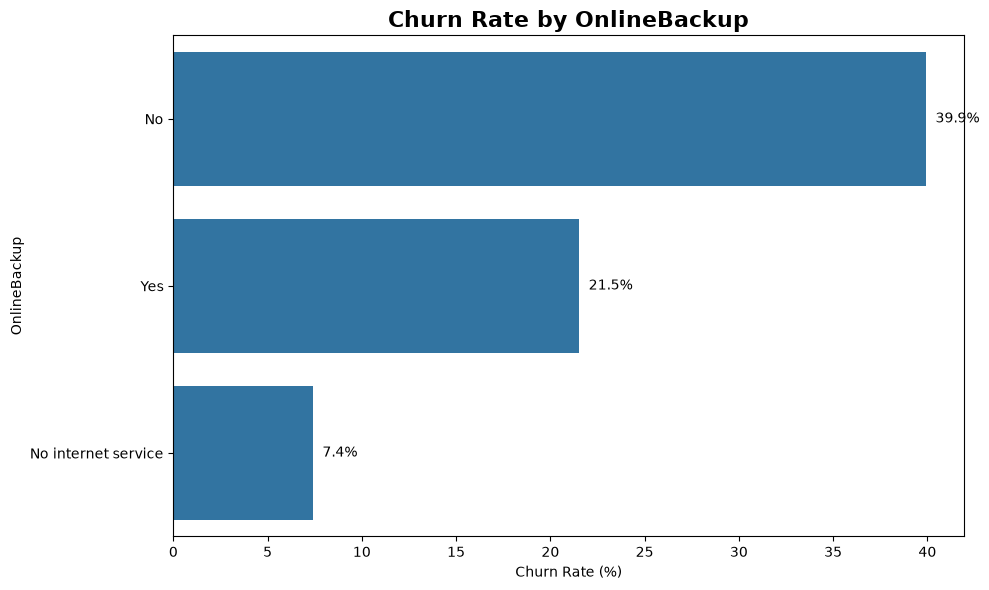

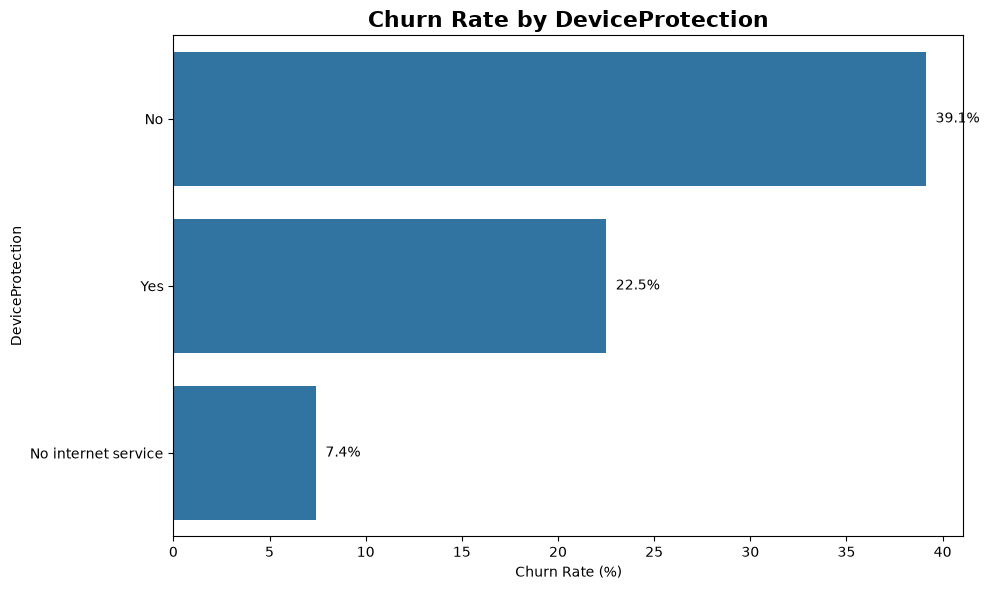

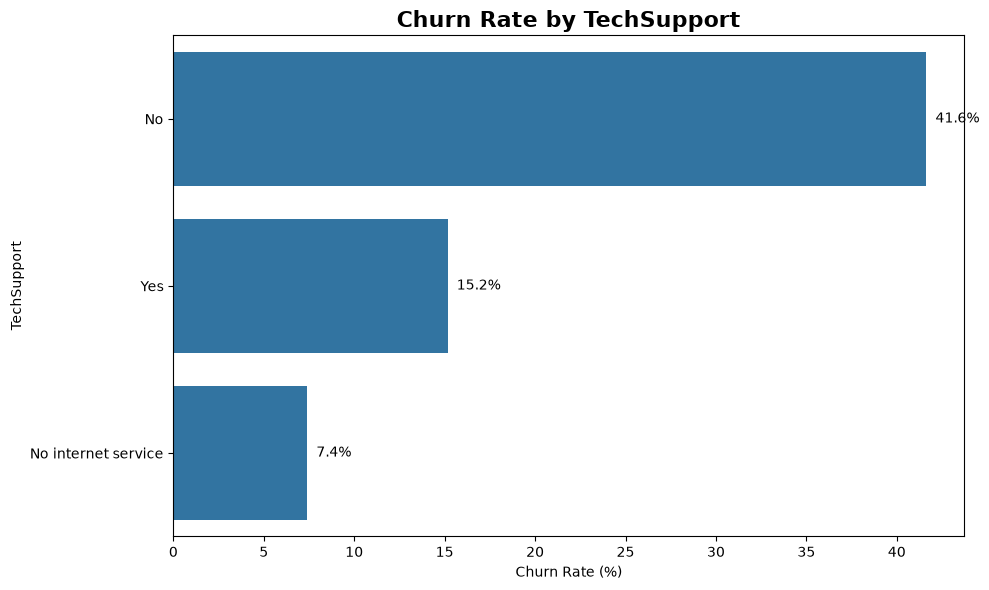

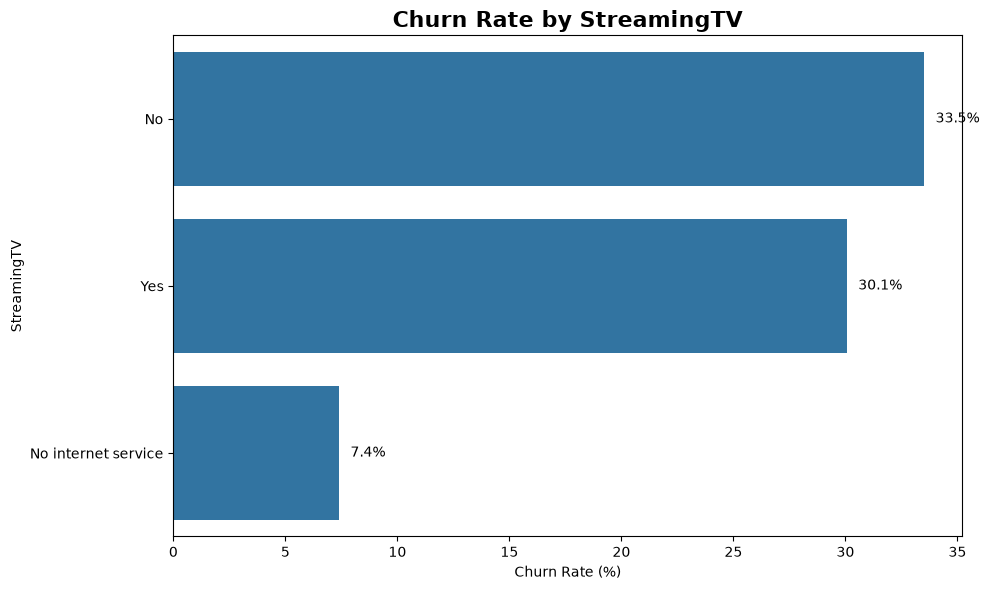

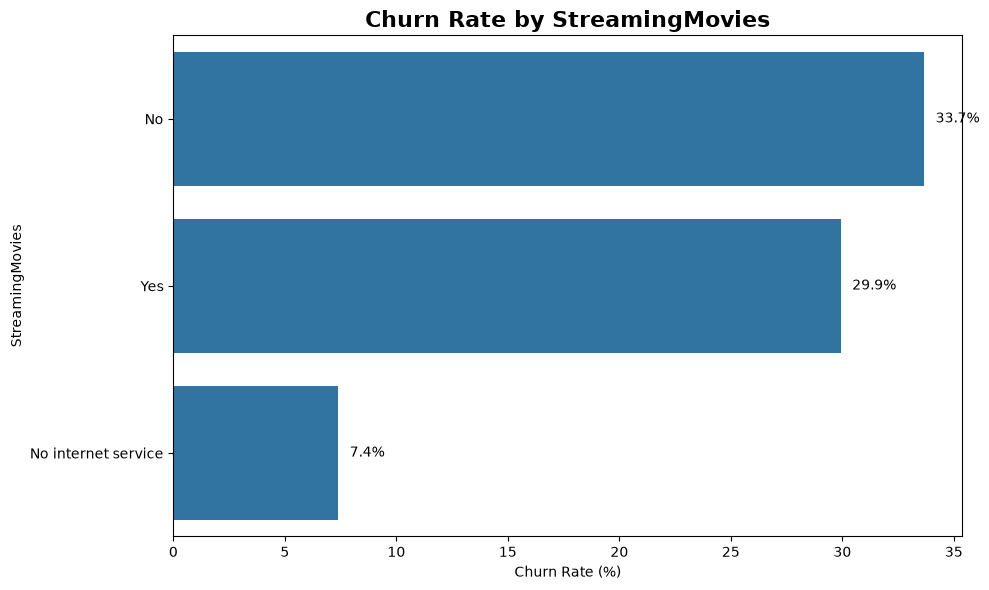

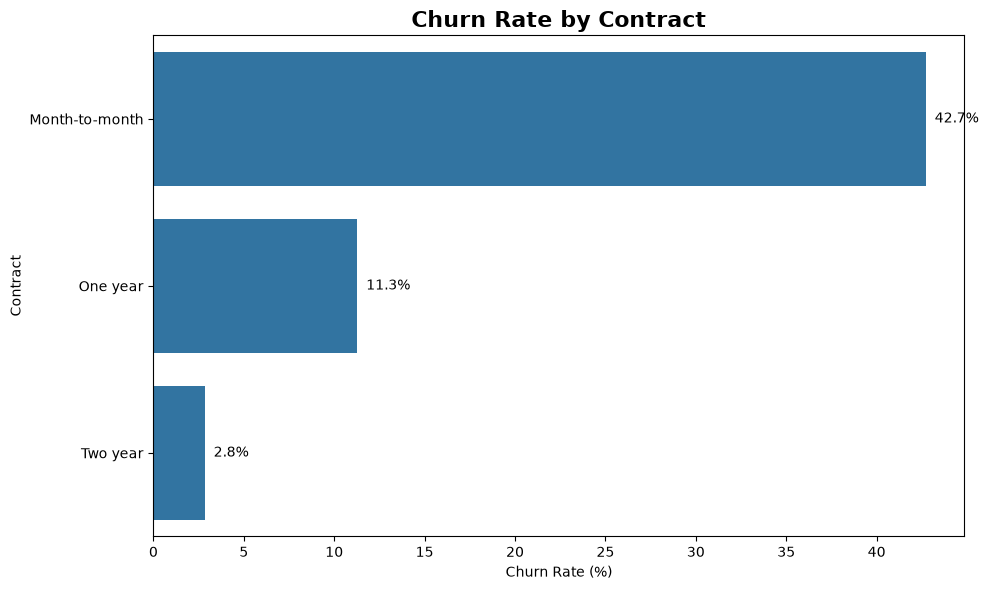

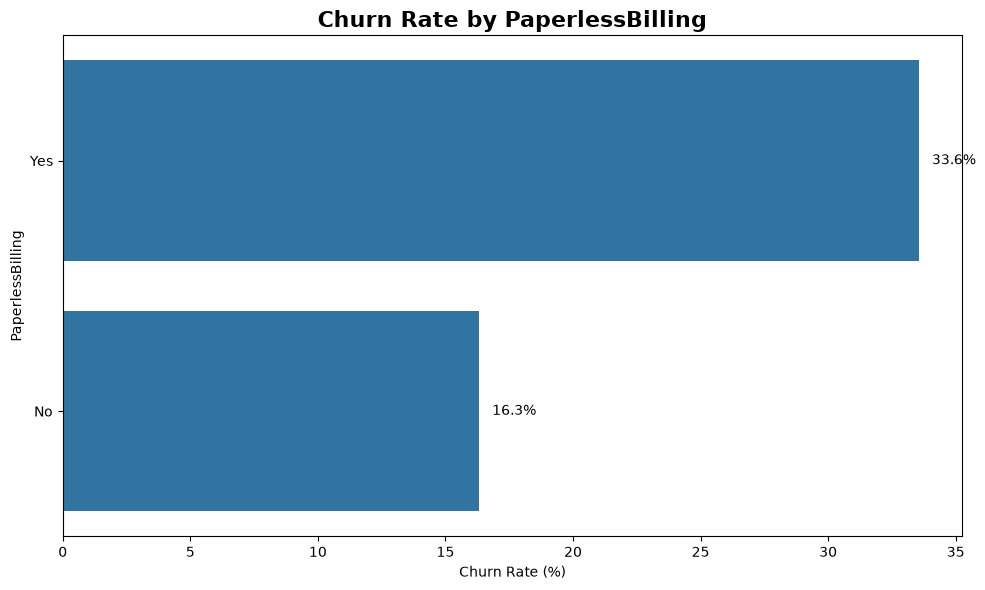

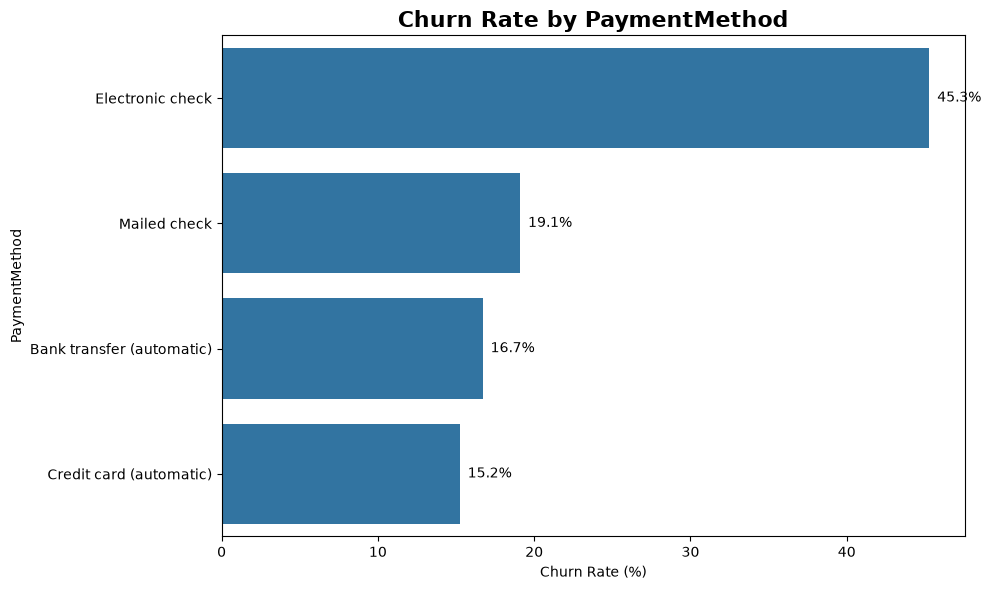

In [28]:
# Categorical churn rate charts

for column in categorical_columns:

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    sns.barplot(
        x=churn_rate.values,
        y=churn_rate.index,
        ax=ax
    )

    ax.set_title(
        f"Churn Rate by {column}",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(column)

    for i, value in enumerate(churn_rate.values):

        ax.text(
            value + 0.5,
            i,
            f"{value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()
    plt.close()

In [22]:
# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================

df_corr = df.copy()

# Convert Churn to numeric
df_corr["Churn_Encoded"] = (
    df_corr["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

# Select numerical columns
correlation_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Encoded"
]

correlation_matrix = (
    df_corr[correlation_columns]
    .corr()
)

display(correlation_matrix)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Encoded
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn_Encoded,0.150889,-0.352229,0.193356,-0.199484,1.000000


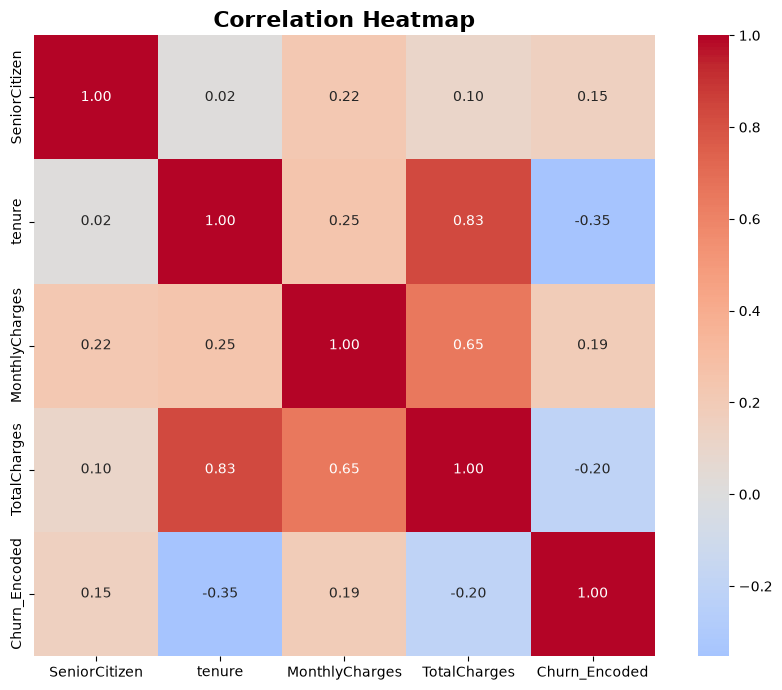

In [24]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax
)

ax.set_title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    reports_dir / "07_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
#Insights

# Overall churn rate
overall_churn_rate = (
    (df["Churn"] == "Yes").mean() * 100
)

# Average tenure
avg_tenure_churned = (
    df.loc[df["Churn"] == "Yes", "tenure"]
    .mean()
)

avg_tenure_retained = (
    df.loc[df["Churn"] == "No", "tenure"]
    .mean()
)

# Average monthly charges
avg_monthly_churned = (
    df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
    .mean()
)

avg_monthly_retained = (
    df.loc[df["Churn"] == "No", "MonthlyCharges"]
    .mean()
)

# Contract churn rates
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

# Internet service churn rates
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

# Payment method churn rates
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"""
1. Overall churn rate

The overall customer churn rate is {overall_churn_rate:.1f}%.
This indicates that approximately one in every four customers
has churned, making customer retention a meaningful business issue.
"""
)

print(
    f"""
2. Tenure and churn

Customers who churned had an average tenure of
{avg_tenure_churned:.1f} months, compared with
{avg_tenure_retained:.1f} months for customers who remained.

This suggests that newer customers may require greater attention
during the early stages of their relationship with the company.
"""
)

print(
    f"""
3. Monthly charges and churn

The average monthly charge for churned customers was
${avg_monthly_churned:.2f}, compared with
${avg_monthly_retained:.2f} for retained customers.

Higher monthly charges appear to be associated with greater
churn risk in this dataset.
"""
)

print(
    f"""
4. Contract structure matters

The contract type with the highest churn rate is
'{contract_churn.index[0]}' at {contract_churn.iloc[0]:.1f}%.

The contract type with the lowest churn rate is
'{contract_churn.index[-1]}' at {contract_churn.iloc[-1]:.1f}%.

Contract design and commitment length may therefore be important
variables for retention strategy.
"""
)

print(
    f"""
5. Internet service is associated with different churn levels

The highest observed churn rate among Internet Service categories
is for '{internet_churn.index[0]}' at {internet_churn.iloc[0]:.1f}%.

The lowest is '{internet_churn.index[-1]}' at
{internet_churn.iloc[-1]:.1f}%.

This suggests that service type and the customer experience
associated with it may be relevant to churn.
"""
)

BUSINESS INSIGHTS

1. Overall churn rate

The overall customer churn rate is 26.5%.
This indicates that approximately one in every four customers
has churned, making customer retention a meaningful business issue.


2. Tenure and churn

Customers who churned had an average tenure of
18.0 months, compared with
37.6 months for customers who remained.

This suggests that newer customers may require greater attention
during the early stages of their relationship with the company.


3. Monthly charges and churn

The average monthly charge for churned customers was
$74.44, compared with
$61.27 for retained customers.

Higher monthly charges appear to be associated with greater
churn risk in this dataset.


4. Contract structure matters

The contract type with the highest churn rate is
'Month-to-month' at 42.7%.

The contract type with the lowest churn rate is
'Two year' at 2.8%.

Contract design and commitment length may therefore be important
variables for retention strategy.


5. Internet 